In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display_latex

In [9]:
#-----------------------------------------Initial conditions for Figure 8------------------------------------------
M = np.array([1, 1, 1])
N = np.size(M)
# Time
dt = 0.01
timesteps = 100000
time = np.linspace(0, dt*timesteps+1, timesteps)

x0 = np.array([[-0.97000436,  0.24308753, 0], 
               [0.97000436, -0.24308753, 0],
               [ 0.0, 0.0, 0]])

v0 = np.array([[0.4662036850, 0.4323657300, 0], 
               [0.4662036850, 0.4323657300, 0],
               [-2*0.4662036850, -2*0.4323657300, 0]])
M[0]*x0[0]

array([-0.97000436,  0.24308753,  0.        ])

In [2]:
#-----------------------------------------Initial Conditions for Two Body Problem----------------------------------
M = np.array([1, 1])
N = np.size(M)
G = 1

# Time
dt = 0.01
timesteps = 5000
time = np.linspace(0, dt*timesteps+1, timesteps)

#Initial conditions for Figure 8 
x0 = np.array([[ 1, 0, 0],
               [-1, 0, 0]])


R = np.linalg.norm(x0[1]-x0[0])
totalM = M[0] + M[1]
v_esc = np.sqrt(2 * G * totalM / R) / N #Escape Velocity
v_rel = np.sqrt(G * totalM / R)

v0= np.array([[0, M[1]/totalM * v_rel, 0],
            [0, -M[0]/totalM * v_rel, 0]])

In [ ]:
def nBodyEulerCromer(M, x0, v0, time):
    
    #Constants
    G = 1
    N = np.size(M)
    colors = plt.cm.viridis(np.linspace(0, 1, N))
    timesteps = np.shape(time)[0]
    dt = time[1] - time[0]

    #Centre of Mass
    CoM0 = np.zeros(3)
    v_CoM0 = np.zeros(3)
    total_mass = np.sum(M, axis= 0)
    
    for i in range(N):
        CoM0 += M[i] * x0[i, :]/total_mass
        v_CoM0 += M[i] * v0[i, :]/total_mass
    
    #Position/Velocity Vectors
    x = np.zeros((N, 3, timesteps))
    v = np.zeros((N, 3, timesteps))
    
    x[:, :, 0] = x0-CoM0
    v[:, :, 0] = v0-v_CoM0

    #Conserved Quantities
    T = np.zeros(timesteps) # KE
    U = np.zeros(timesteps) # PE
    P = np.zeros((3, timesteps)) # Momentum
    L = np.zeros((3, timesteps))

    for i in range(N):
        x_i = x[i, :, 0]
        u_i = v[i, :, 0]
        T_i = 0.5*M[i]*np.linalg.norm(u_i)**2
        P_i = M[i] * u_i
        L_i = np.cross(x_i, P_i)
        
        T[0] += T_i
        P[:, 0] += P_i
        L[:, 0] += L_i
        
        for j in range(i+1, N):
            r_ij = x[j, :, 0] - x[i, :, 0]
            U_ij = G*M[i]*M[j]/(np.linalg.norm(r_ij))
            U[0] -= U_ij 
        
    for k in range(timesteps-1):
        for i in range(N):
            a_i = np.zeros(3)
            for j in range(N):
                x_i, x_j = x[i, :, k], x[j, :, k]
                r_ij = x_j - x_i
                if i > j:
                    #Calculate force exerted on i by each j
                    a_ij = (G*M[j]/(np.linalg.norm(r_ij)**3)) * (r_ij)
                    a_i += a_ij
                    
                    #Calculating potentials
                    U_ij = G*M[i]*M[j]/(np.linalg.norm(r_ij))
                    U[k+1] -= U_ij 
                elif i < j:
                    #Calculate force exerted on i by each j
                    a_ij = (G*M[j]/(np.linalg.norm(r_ij)**3)) * (r_ij)
                    a_i += a_ij
                    
            #Euler Updates
            x_i, u_i = x[i, :, k], v[i, :, k]
            v[i, :, k+1] = (u_i + dt*a_i)
            
            v_i = v[i, :, k+1]
            x[i, :, k+1] = (x_i + dt*v_i)

            #Take KE of each particle at time t
            T_i = 0.5*M[i]*np.linalg.norm(v_i)**2
            T[k+1] += T_i
        
            #Take momentum of each particle at time k
            P_i = M[i]*v_i
            L_i = np.cross(x[i, :, k+1], P_i)
            
            P[:, k+1] += P_i
            L[:, k+1] += L_i
            
    #Conserved Quantities Errors
    E = T + U
    P0, P_error_denominator = P[:, 0], P[:, 0]
    L0, L_error_denominator = L[:, 0], L[:, 0]
    E_error = np.abs((E-E[0])/E[0])
    
    if np.abs(E[0]) == 0:
        for i in range(N):
            v0_i = v0[i, :]
            if np.linalg.norm(v0_i) != 0:
                P_error_denominator = M[i]*v0_i
                break
    
    if np.linalg.norm(P[:, 0]) == 0:
        for i in range(N):
            v0_i = v0[i, :]
            if np.linalg.norm(v0_i) != 0:
                P_error_denominator = M[i]*v0_i
                break
    
    if np.linalg.norm(L[:, 0]) == 0:
        for i in range(N):
            x0_i = x0[i, :]
            v0_i = v0[i, :]
            P0_i = M[i]*v0_i
            L0_i = np.cross(x0_i, P0_i)
            if np.linalg.norm(L0_i) != 0:
                L_error_denominator = L0_i
                break
    
    P_error = np.linalg.norm((P-P0[:, None]), axis = 0)/np.linalg.norm(P_error_denominator)
    L_error = np.linalg.norm((L-L0[:, None]), axis = 0)/np.linalg.norm(L_error_denominator)
    
    # Plotting the orbits
    fig1, axa = plt.subplots()
    #axa.scatter(0, 0, color = 'black', label = "Centre of Mass")
    for i in range(N):
        axa.plot(x[i, 0, :], x[i, 1, :], color = colors[i], label = f"Body {i+1}")
        axa.scatter(x0[i, 0], x0[i, 1], color = colors[i], label = f"Mass {M[i]} Start ")
        axa.scatter(x[i, 0, -1], x[i, 1, -1], facecolor = 'None', edgecolor = colors[i], label = f"Mass {M[i]} End ")
        plt.gca().set_aspect('equal', adjustable='box')
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

    fig2, axb = plt.subplots(3, 1, figsize = (10, 15))
    axb[0].plot(time, E_error)
    axb[0].set_title("Energy Error")
    axb[1].plot(time, P_error)
    axb[1].set_title("Momentum Error")
    axb[2].plot(time, L_error)
    axb[2].set_title("Ang. Momentum Error")
    plt.tight_layout()
    return x, v

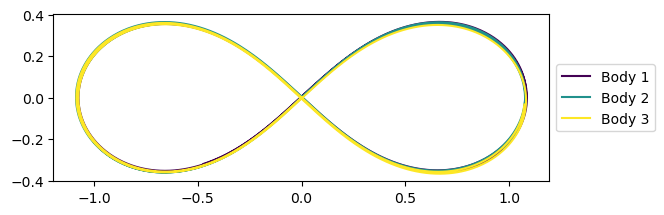

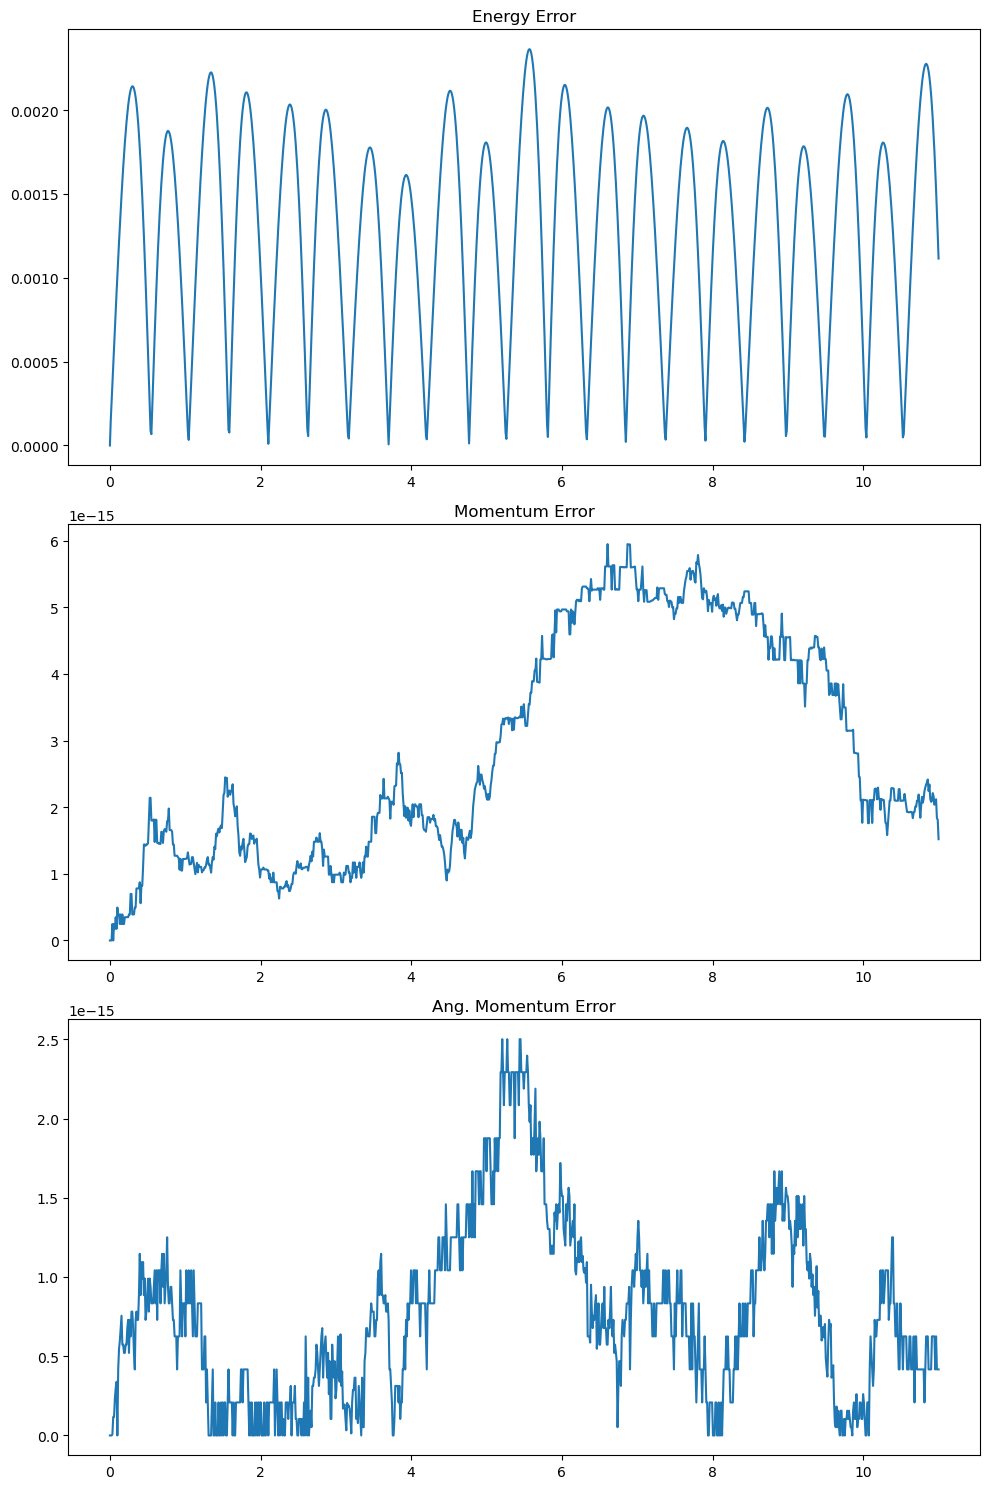

In [8]:
x_ECr, v_ECr = nBodyEulerCromer(M, x0, v0, time)